# Dating Survey — Question Similarity Analysis
Projects all 39 survey questions into 2D using PCA, so questions answered similarly cluster together.
Three coloring modes: by category, answer variance, and couple disagreement.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('dating_app_survey_responses.csv')
print(df.shape)
df.head()

(50, 41)


,User_ID,Pair_Role,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,Q30,Q31,Q32,Q33,Q34,Q35,Q36,Q37,Q38,Q39
0,User_1,User 1,6,3,4,6,2,4,4,6,...,4,3,0,0,1,2,3,1,3,3
1,User_2,User 2,6,5,5,6,5,2,3,6,...,3,6,3,6,4,3,3,4,3,4
2,User_3,User 1,3,1,3,1,5,5,5,1,...,1,6,4,1,5,5,4,4,4,6
3,User_4,User 2,4,6,4,0,0,6,0,0,...,6,5,4,2,1,1,2,1,1,2
4,User_5,User 1,4,6,5,2,0,4,1,6,...,6,4,6,2,5,3,4,4,4,4


In [ ]:
# ── Question metadata ─────────────────────────────────────────────────────────
questions = [
    # Core Values (0–5)
    "Honesty prioritized, even if it hurts",
    "Religion/spirituality important in life",
    "Political beliefs matter in choosing partner",
    "Family before career",
    "Personal independence important",
    "Helping others / giving back important",
    # Lifestyle (6–11)
    "Prefer structured daily routine",
    "Socialize frequently (restaurants/parties)",
    "Financial saving over experiences",
    "Value a lot of personal alone time",
    "Prefer quiet environment",
    "Physical health & exercise top priority",
    # Communication (12–17)
    "Talk through problems immediately",
    "Comfortable discussing emotions openly",
    "Frequent texts/calls important",
    "Direct/honest communication (even blunt)",
    "Comfortable sharing personal struggles",
    "Resolve misunderstandings quickly",
    # Intimacy (18–23)
    "Physical affection very important",
    "Verbal expressions of love important",
    "Sexual compatibility essential",
    "Quality time with partner important",
    "Romantic gestures important",
    "Frequent affection expressions",
    # Conflict (24–29)
    "Resolve arguments before sleeping",
    "Compromise most important in conflicts",
    "Apologize quickly after argument",
    "Prefer calm vs emotional arguments",
    "Time apart during conflict helpful",
    "Disagreements can strengthen relationship",
    # Future Goals (30–35)
    "Want to get married eventually",
    "Having children important",
    "Career success top priority",
    "Willing to move for partner",
    "Financial stability before major decisions",
    "Long-term planning important",
    # Relationship Certainty (36–38)
    "Confident about relationship future",
    "Worry partner & I want different things",
    "Believe we are highly compatible",
]

categories = (
    [0]*6 + [1]*6 + [2]*6 + [3]*6 + [4]*6 + [5]*6 + [6]*3
)

cat_names  = ['Core Values','Lifestyle','Communication','Intimacy','Conflict','Future Goals','Rel. Certainty']
cat_colors = ['#534AB7','#0F6E56','#D85A30','#993556','#185FA5','#639922','#BA7517']

In [ ]:
# ── Build question × user matrix and run PCA ──────────────────────────────────
q_cols = [c for c in df.columns if c.startswith('Q')]
data   = df[q_cols].values          # shape: (50 users, 39 questions)

# Transpose so rows = questions, cols = users
Q = data.T                          # (39, 50)

scaler = StandardScaler()
Q_scaled = scaler.fit_transform(Q)  # z-score each question across users

pca = PCA(n_components=2)
coords = pca.fit_transform(Q_scaled)

print(f"Variance explained — PC1: {pca.explained_variance_ratio_[0]:.1%}  "
      f"PC2: {pca.explained_variance_ratio_[1]:.1%}")

Variance explained — PC1: 13.5%  PC2: 8.3%


In [ ]:
# ── Compute per-question statistics ──────────────────────────────────────────
variances = Q.std(axis=1)           # std across all users

# Couple disagreement: mean |score_member1 - score_member2| per question
user1_rows = df[df['Pair_Role'] == 'User 1'][q_cols].values  # (25, 39)
user2_rows = df[df['Pair_Role'] == 'User 2'][q_cols].values  # (25, 39)
couple_diff = np.abs(user1_rows - user2_rows).mean(axis=0)   # (39,)

In [ ]:
# ── Helper: build a single scatter panel ─────────────────────────────────────
def plot_panel(ax, color_values, cmap, title, cbar_label, annotate=False):
    sc = ax.scatter(
        coords[:, 0], coords[:, 1],
        c=color_values, cmap=cmap,
        s=120, zorder=3, linewidths=0.8, edgecolors='white'
    )
    plt.colorbar(sc, ax=ax, label=cbar_label, fraction=0.03, pad=0.02)
    ax.set_title(title, fontsize=12, fontweight='500', pad=8)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=10)
    ax.axhline(0, color='#ccc', lw=0.5, zorder=1)
    ax.axvline(0, color='#ccc', lw=0.5, zorder=1)
    ax.set_facecolor('#fafafa')
    ax.grid(True, color='#ececec', linewidth=0.5, zorder=0)
    if annotate:
        for i, q in enumerate(questions):
            ax.annotate(
                q, (coords[i, 0], coords[i, 1]),
                fontsize=6.5, ha='left', va='bottom',
                xytext=(4, 3), textcoords='offset points', color='#444'
            )

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

for cat_idx, cat_name in enumerate(cat_names):
    mask = [i for i, c in enumerate(categories) if c == cat_idx]
    fig.add_trace(go.Scatter(
        x=[coords[i, 0] for i in mask],
        y=[coords[i, 1] for i in mask],
        mode='markers',
        name=cat_name,
        marker=dict(
            color=cat_colors[cat_idx],
            size=12,
            line=dict(width=1, color='white')
        ),
        text=[questions[i] for i in mask],
        hovertemplate='<b>%{text}</b><extra></extra>',
        customdata=mask
    ))

fig.update_layout(
    title='Question Similarity Map',
    xaxis_title=f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
    yaxis_title=f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
    width=900,
    height=650,
    plot_bgcolor='#fafafa',
    legend=dict(itemclick='toggle', itemdoubleclick='toggleothers'),
    hovermode='closest'
)

fig.add_hline(y=0, line_width=0.5, line_color='#ccc')
fig.add_vline(x=0, line_width=0.5, line_color='#ccc')

fig.show()
fig.write_html("question_similarity.html", include_plotlyjs='cdn')


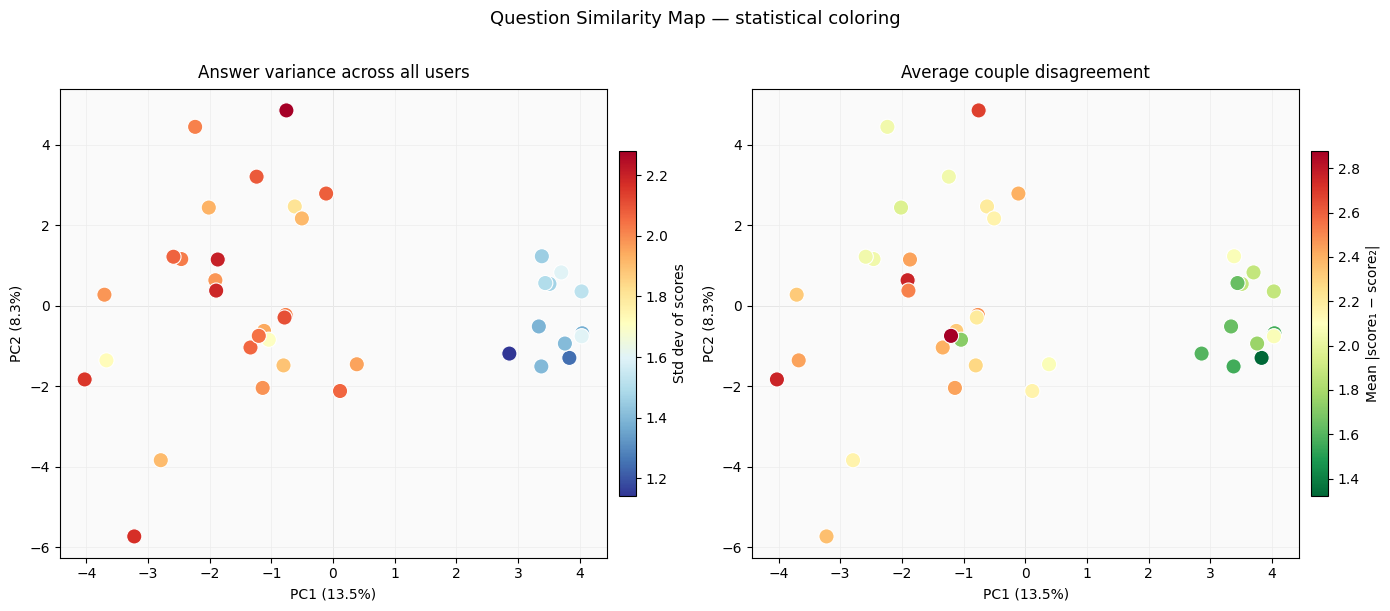

In [ ]:

# ── Figure 2: Variance + couple disagreement side by side ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_panel(
    axes[0], variances, 'RdYlBu_r',
    'Answer variance across all users',
    'Std dev of scores'
)
plot_panel(
    axes[1], couple_diff, 'RdYlGn_r',
    'Average couple disagreement',
    'Mean |score₁ − score₂|'
)

plt.suptitle('Question Similarity Map — statistical coloring', fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('question_similarity_stats.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Question'        : questions,
    'Category'        : [cat_names[c] for c in categories],
    'PC1'             : coords[:, 0].round(3),
    'PC2'             : coords[:, 1].round(3),
    'Variance'        : variances.round(3),
    'Couple_Diff'     : couple_diff.round(3),
})

summary = summary.sort_values('Couple_Diff', ascending=False)
print("Top 10 questions with highest couple disagreement:")
summary.head(10)

Top 10 questions with highest couple disagreement:


,Question,Category,PC1,PC2,Variance,Couple_Diff
29,Disagreements can strengthen relationship,Conflict,-1.203,-0.753,2.043,2.88
24,Resolve arguments before sleeping,Conflict,-1.907,0.629,1.982,2.76
11,Physical health & exercise top priority,Lifestyle,-4.026,-1.835,2.154,2.76
1,Religion/spirituality important in life,Core Values,-0.755,4.849,2.280,2.68
25,Compromise most important in conflicts,Conflict,-1.894,0.372,2.191,2.52
4,Personal independence important,Core Values,-0.768,-0.234,2.016,2.48
20,Sexual compatibility essential,Intimacy,-1.869,1.144,2.204,2.44
22,Romantic gestures important,Intimacy,-1.140,-2.046,1.985,2.44
2,Political beliefs matter in choosing partner,Core Values,-3.673,-1.362,1.724,2.44
28,Time apart during conflict helpful,Conflict,-1.338,-1.042,2.065,2.40


NameError: name 'fig' is not defined